In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
import shap
from shap.plots import waterfall
from shap import TreeExplainer, Explanation,summary_plot
import joblib

/home/aswathy/machine_learning projects/xai_prediction/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def change_column_name(col):
    new_col_name = col.lower().strip().replace(" ","_")
    reg = r"\[(.*?)\]"
    new_col_name = re.sub(reg,"",new_col_name)
    if(new_col_name.endswith("_")):
        new_col_name= new_col_name[:-1]
        
    return new_col_name

In [3]:
def plot_SHAP(record_index,output_class_name="main_failure_0"):
    exp_matrix ={
    "main_failure_0":0,
    "main_failure_1":1,
    "bef_0":2,
    "bef_1":3,
    "ccf_0":4,
    "ccf_1":5,
    "fwf_0":6,
    "fwf_1":7,
    "wdf_0":8,
    "wdf_1":9
}
    

    output_fail_idx = exp_matrix[output_class_name]
    

    base = X_trans.index.get_loc(record_index)

    output_fail_exp = shap.Explanation(
        values=shap_values.values[base,:,output_fail_idx],
        base_values=shap_values.base_values[base,output_fail_idx],
        data=X_trans.iloc[base],
        feature_names=X_trans.columns
        
        )
    

    print(output_fail_exp.data)
    print(y_train.iloc[base])  
    shap.plots.waterfall(output_fail_exp,max_display=15)


In [4]:
df = pd.read_csv("../data/XAI_Drilling_Dataset.csv")
print(df.head())

   ID  Cutting speed vc [m/min]  Spindle speed n [1/min]  Feed f [mm/rev]  \
0   1                     29.92                      794            0.218   
1   2                     29.85                      792            0.241   
2   3                     22.85                      606            0.183   
3   4                     29.60                      785            0.236   
4   5                     17.43                      462            0.246   

   Feed rate vf [mm/min]  Power Pc [kW]  Cooling [%] Material Drill Bit Type  \
0                    173         194.87           75        N              W   
1                    191         214.71           75        N              W   
2                    111          95.68           50        P              N   
3                    237         206.93           75        N              W   
4                    114          74.85           50        K              H   

   Process Time [sec]  Main Failure  BEF  CCF  FWF  WDF 

In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        20000 non-null  int64  
 1   Cutting speed vc [m/min]  20000 non-null  float64
 2   Spindle speed n [1/min]   20000 non-null  int64  
 3   Feed f [mm/rev]           20000 non-null  float64
 4   Feed rate vf [mm/min]     20000 non-null  int64  
 5   Power Pc [kW]             20000 non-null  float64
 6   Cooling [%]               20000 non-null  int64  
 7   Material                  20000 non-null  str    
 8   Drill Bit Type            20000 non-null  str    
 9   Process Time [sec]        20000 non-null  float64
 10  Main Failure              20000 non-null  int64  
 11  BEF                       20000 non-null  int64  
 12  CCF                       20000 non-null  int64  
 13  FWF                       20000 non-null  int64  
 14  WDF              

In [6]:
print(df.describe())

                 ID  Cutting speed vc [m/min]  Spindle speed n [1/min]  \
count  20000.000000              20000.000000             20000.000000   
mean   10000.500000                 23.322470               618.644400   
std     5773.647028                  5.174178               137.248701   
min        1.000000                 16.330000               433.000000   
25%     5000.750000                 17.590000               467.000000   
50%    10000.500000                 22.610000               600.000000   
75%    15000.250000                 29.780000               790.000000   
max    20000.000000                 31.070000               824.000000   

       Feed f [mm/rev]  Feed rate vf [mm/min]  Power Pc [kW]   Cooling [%]  \
count     20000.000000           20000.000000   20000.000000  20000.000000   
mean          0.224831             140.629850     128.992781     56.750000   
std           0.037563              41.470466      65.403239     23.941933   
min           0.10800

In [7]:
df.rename(change_column_name,inplace=True,axis="columns")
df.to_csv("../data/cleaned_xai_drilling_dataset.csv")

In [8]:
df.isna().sum()

id                  0
cutting_speed_vc    0
spindle_speed_n     0
feed_f              0
feed_rate_vf        0
power_pc            0
cooling             0
material            0
drill_bit_type      0
process_time        0
main_failure        0
bef                 0
ccf                 0
fwf                 0
wdf                 0
dtype: int64

In [9]:
falied_df=df.query(("main_failure ==0"))

falied_df = falied_df.query(("bef == 1")or ("ccf== 1") or ("wdf == 1") or ("fwf == 1"))


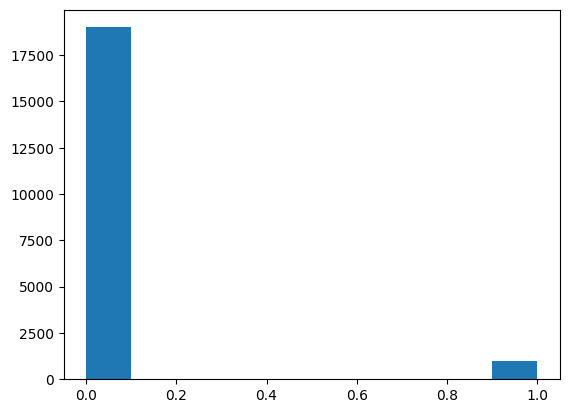

In [10]:
plt.hist(df["main_failure"])
plt.show()

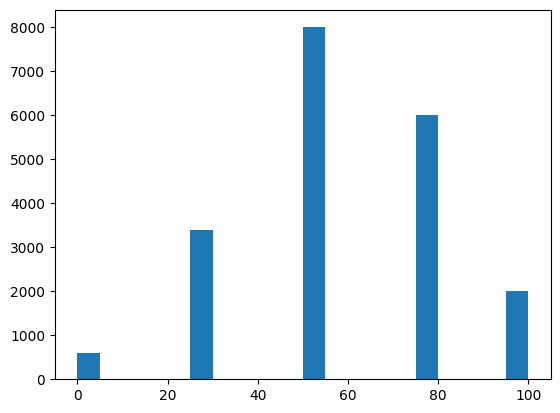

In [11]:
plt.hist(df["cooling"],bins=20)
plt.show()

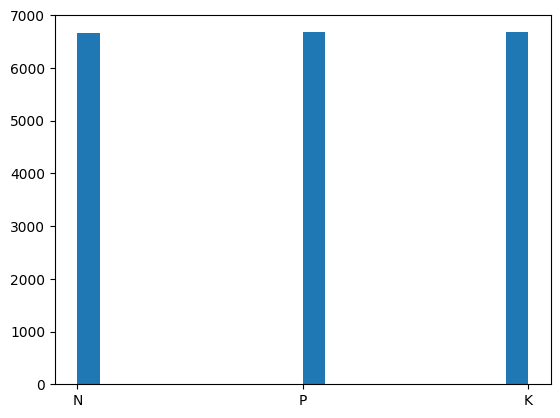

In [12]:
plt.hist(df["material"],bins=20)
plt.show()

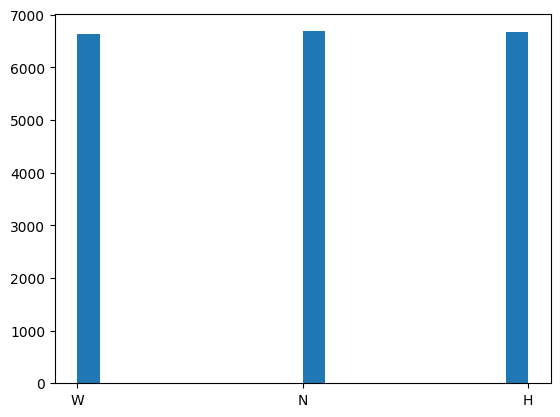

In [13]:
plt.hist(df["drill_bit_type"],bins=20)
plt.show()

In [14]:



# df["fail_cat"] = df.apply(lambda x:f"{x['bef']}{x['ccf']}{x['fwf']}{x['wdf']}", axis=1)

# print(df["fail_cat"].unique())
# le = LabelEncoder()


# df["fail_cat"] = le.fit_transform(df["fail_cat"])

# target ="fail_cat"
target=["main_failure","bef","ccf","fwf","wdf"]

# X=df.drop(columns=["main_failure","bef","ccf","fwf","wdf","id","fail_cat"])
X=df.drop(columns=["main_failure","bef","ccf","fwf","wdf","id"])
y= df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3,random_state=42)

In [15]:
classifier = RandomForestClassifier(n_estimators=100, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat",OneHotEncoder(handle_unknown="error",sparse_output=False),["material","drill_bit_type"])
    ],remainder="passthrough"
)
pipeline =Pipeline(
    steps=[
        ("preprocess",preprocessor),
        ("model",classifier)]
)

pipeline.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

In [16]:

feat = pipeline[:-1].get_feature_names_out()
y_predict = pipeline.predict(X_test)

# X_train =pd.get_dummies(X_train)
# classifier.fit(X_train,y_train)

# y_predict = classifier.predict(X_test)
y_predict = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_predict)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 99.75%


In [17]:
# import shap
# explainer = shap.TreeExplainer(classifier)

# X_trans = preprocessor.fit_transform(X_train)
# shap_values = explainer(X_trans)

# # visualize the first prediction's explanation
# # shap.plots.waterfall(shap_values[0])

# shap.summary_plot(shap_values, X_trans)
# shap.dependence_plot('spindle_speed_n', shap_values[0], X_test)
# s= pipeline._required_parameters()

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

In [18]:
# conf_matrix = confusion_matrix(y_test, y_predict)
# # plt.barh(df.columns, feature_importances)
# # plt.xlabel('Feature Importance')
# # plt.title('Feature Importance in Random Forest Classifier')
# # plt.show()

# plt.figure(figsize=(5, 5))
# sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False, 
#             xticklabels=target, yticklabels=target)

# plt.title('Confusion Matrix Heatmap')
# plt.xlabel('Predicted Labels')
# plt.ylabel('True Labels')
# plt.show()


In [19]:
# df_trans = pd.get_dummies(df)

# # Define the list of the one-hot encoded columns for 'Product Category'
# material_category_columns = ['material_K', 'material_N', 'material_P']

# # Sum the SHAP values for these columns to get the total SHAP value for 'Product Category'
# shap_values_product_category = np.sum(shap_values[:, material_category_columns], axis=1)

In [20]:
# get the feature names
# features = cv.get_feature_names_out()

# create a DataFrame from the bag of words 
imp = classifier.feature_importances_

fi = {
    "feat":feat,
    "imp":imp
    
}
df_bow = pd.DataFrame(data=fi)
# feats=classifier.feature_names_in_

In [21]:
shap.initjs()
preprocessor.set_output(transform="pandas")
X_trans = preprocessor.fit_transform(X_train)
explainer = TreeExplainer(classifier,feature_names=X_trans.columns,feature_perturbation="tree_path_dependent",data=X_trans)

shap_values = explainer(X_trans,y=y_train)

In [22]:
np.shape(shap_values.values)

(14000, 13, 10)

In [23]:

class_idx = 8
row_idx = 150
expected_value = explainer.expected_value[class_idx]
shap_value = shap_values[:, :, class_idx].values[row_idx]


shap.force_plot(
    base_value=expected_value,
    shap_values=shap_value,
    features=X_trans.iloc[row_idx, :],
    link="logit",
)

# indx = 25
# choosen_instance = X_trans.loc[[indx]]

# shap.initjs()
# shap.force_plot(explainer.expected_value[1][0], X_trans.iloc[0,:], choosen_instance)

# shap.force_plot(explainer.expected_value[1], shap_values[1][0], X_trans.iloc[0,:])


# shap_values = explainer.shap_values(X_trans)

# choosen_instance = X_trans.iloc[[421]]
# shap_values = explainer.shap_values(choosen_instance)
# shap.initjs()
# shap.force_plot(explainer.expected_value[3], shap_values[1], choosen_instance)

In [24]:

# choosen_instance = X_trans.iloc[[5]]
# shap_values = explainer.shap_values(choosen_instance)
# shap.initjs()
# shap.force_plot(explainer.expected_value[0], shap_values[0], choosen_instance)


In [25]:
# sample_idx = 0  # You can change this to explore different houses
# sample_prediction = pipeline.predict(X_test.iloc[[sample_idx]])[0]
# actual_price = y_test.iloc[sample_idx]

In [26]:
# # Create SHAP waterfall plot
# plt.figure(figsize=(12, 8))
# shap.waterfall_plot(
#     shap.Explanation(
#         values=shap_values[0], 
#         base_values=explainer.expected_value, 
#         data=X_test.iloc[sample_idx],
#         feature_names=X_test.columns.tolist()
#     ),
#     max_display=15,  # Show top 15 contributing features
#     show=False
# )
# plt.title(f'How Our Model Predicts ${sample_prediction:,.0f} for This House', 
#           fontsize=14, fontweight='bold', pad=20)
# plt.tight_layout()
# plt.show()

In [27]:
np.shape(shap_values.base_values)

(14000, 10)

In [28]:
print(shap_values.base_values[11295])

[0.19192 0.00808 0.2     0.      0.19594 0.00406 0.19798 0.00202 0.198
 0.002  ]


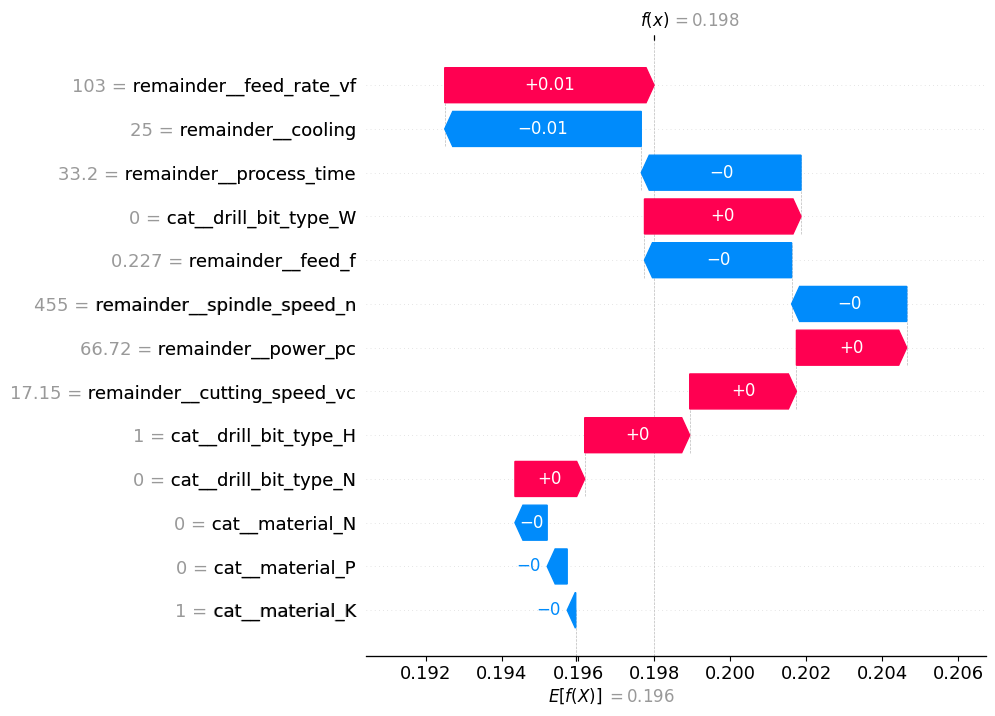

In [29]:
output_class_idx = 4
exp = Explanation(shap_values.values[:,:,output_class_idx], 
                  shap_values.base_values[:,output_class_idx], 
                  data=X_trans.values,
                  output_names="fail_cat",
                  feature_names=X_trans.columns)
idx = 11295
waterfall(exp[idx],show=True,max_display=15)

In [30]:

class_names = {
    0: "main_failure_0",
    1: "main_failure_1",
    2: "bef_0",
    3: "bef_1",
    4: "ccf_0",
    5: "ccf_1",
    6: "fwf_0",
    7: "fwf_1",
    8: "wdf_0",
    9: "wdf_1",
}

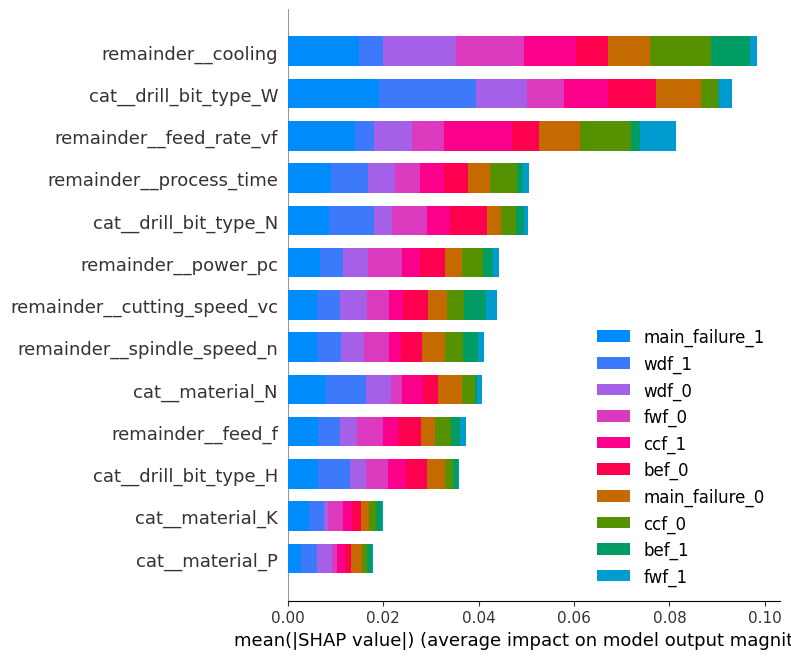

In [31]:
summary_plot(shap_values, feature_names = X_trans.columns,class_names=class_names)

In [32]:
data={
    'cutting_speed_vc':[10], 
    'spindle_speed_n':[800], 
    'feed_f':[11], 
    'feed_rate_vf':[55], 
    'power_pc':[75], 
    'cooling':[50], 
    'process_time':[30],
    'material':['P'],
    'drill_bit_type':['H']
}




pred_df = pd.DataFrame(data=[[10,800,11,55,75,50,30,'P','H']],columns=['cutting_speed_vc', 
    'spindle_speed_n', 
    'feed_f', 
    'feed_rate_vf', 
    'power_pc', 
    'cooling', 
    'process_time',
    'material',
    'drill_bit_type'])

res =pipeline.predict(pred_df)
print(res)

[[1 0 0 0 0]]


/home/aswathy/machine_learning projects/xai_prediction/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [33]:
joblib.dump(pipeline,compress=3,filename="../models/xai.joblib")

['../models/xai.joblib']

In [34]:
out_res=y_train.groupby(["main_failure","bef","ccf","fwf","wdf"]).size().reset_index().rename(columns={0:'count'})

In [35]:
X_trans.loc[11295]


cat__material_K                  1.000
cat__material_N                  0.000
cat__material_P                  0.000
cat__drill_bit_type_H            1.000
cat__drill_bit_type_N            0.000
cat__drill_bit_type_W            0.000
remainder__cutting_speed_vc     17.260
remainder__spindle_speed_n     458.000
remainder__feed_f                0.232
remainder__feed_rate_vf        138.000
remainder__power_pc             69.190
remainder__cooling              25.000
remainder__process_time         32.740
Name: 11295, dtype: float64

In [36]:

y_train.loc[11295]

main_failure    1
bef             0
ccf             1
fwf             0
wdf             0
Name: 11295, dtype: int64

In [37]:
# ## main Failure
# record_idx = 11295
# output_fail_idx = exp_matrix["ccf_1"]

# output_fail_exp = shap.Explanation(
#     values=shap_values.values[record_idx,:,output_fail_idx],
#     base_values=shap_values.base_values[record_idx,output_fail_idx],
#     data=X_trans.loc[record_idx],
#     feature_names=X_trans.columns
    
#     )
# output_fail_exp.data


In [38]:
# shap.plots.waterfall(output_fail_exp,max_display=15)


cat__material_K                  1.000
cat__material_N                  0.000
cat__material_P                  0.000
cat__drill_bit_type_H            1.000
cat__drill_bit_type_N            0.000
cat__drill_bit_type_W            0.000
remainder__cutting_speed_vc     17.260
remainder__spindle_speed_n     458.000
remainder__feed_f                0.232
remainder__feed_rate_vf        138.000
remainder__power_pc             69.190
remainder__cooling              25.000
remainder__process_time         32.740
Name: 11295, dtype: float64
main_failure    1
bef             0
ccf             1
fwf             0
wdf             0
Name: 11295, dtype: int64


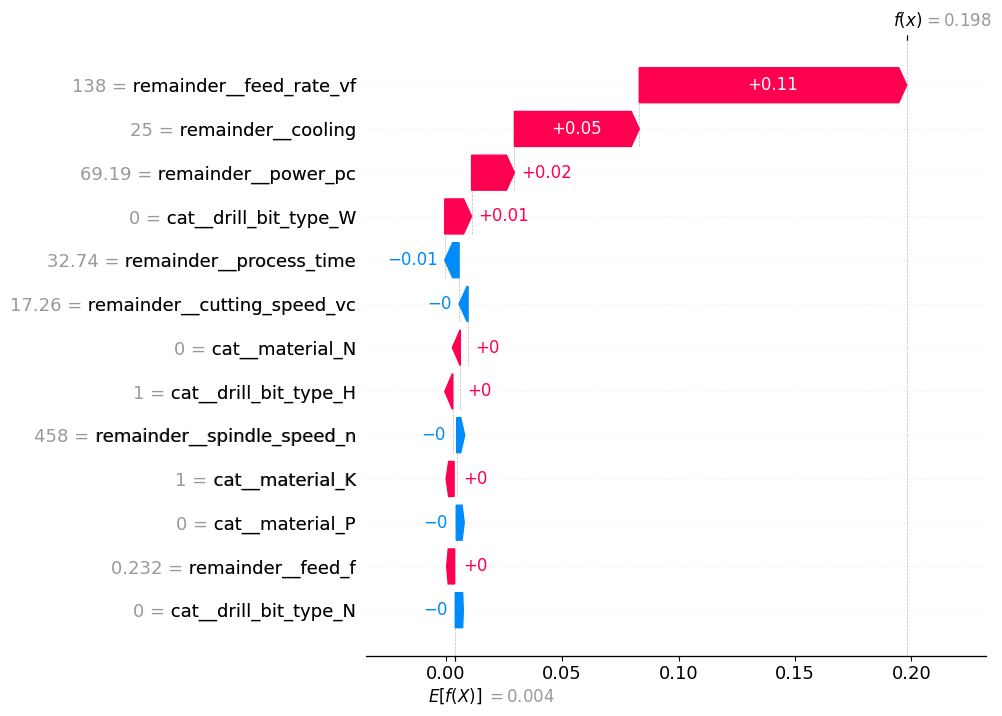

In [39]:
plot_SHAP(record_index=11295,output_class_name="ccf_1")

In [40]:
base = X_trans.index.get_loc(11295)
print (base)

2


In [41]:
X_trans.iloc[base]

cat__material_K                  1.000
cat__material_N                  0.000
cat__material_P                  0.000
cat__drill_bit_type_H            1.000
cat__drill_bit_type_N            0.000
cat__drill_bit_type_W            0.000
remainder__cutting_speed_vc     17.260
remainder__spindle_speed_n     458.000
remainder__feed_f                0.232
remainder__feed_rate_vf        138.000
remainder__power_pc             69.190
remainder__cooling              25.000
remainder__process_time         32.740
Name: 11295, dtype: float64

In [42]:
print(shap_values.output_names)

['Output 0', 'Output 1', 'Output 2', 'Output 3', 'Output 4', 'Output 5', 'Output 6', 'Output 7', 'Output 8', 'Output 9']


In [43]:
probs= classifier.predict_proba(X_trans.iloc[[11295]])
print(probs)

[array([[0.99, 0.01]]), array([[1., 0.]]), array([[0.99, 0.01]]), array([[1., 0.]]), array([[1., 0.]])]


/home/aswathy/machine_learning projects/xai_prediction/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
